# ETC Impacts on the Great Lakes: Impact Analysis

This notebook quantifies differences in extreme lake impacts between the two storm types identified by the Gaussian mixture model. It defines precipitation and evaporation extremes, estimates the probability of extreme impacts for each storm type, and summarizes those differences using risk ratios and risk differences with bootstrap uncertainty intervals.

The resulting tables are saved for use in the figure-generation notebook.

In [1]:
# ------------------------------
# 1. Imports and setup
# ------------------------------
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

REPO_ROOT = Path.cwd().resolve().parent
PROCESSED_DIR = REPO_ROOT / "processed"

print("Repo root:", REPO_ROOT)
print("Processed dir:", PROCESSED_DIR)

Repo root: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes
Processed dir: /Users/dannes/Projects/etc-impacts-great-lakes/etc-impacts-great-lakes/processed


## Configuration

This section defines the input data source, storm-type labels, lake and season ordering, the quantiles used to define extremes, and the bootstrap settings used throughout the notebook.

In [2]:
# ------------------------------
# 2. Configuration
# ------------------------------
CSV_PATH = PROCESSED_DIR / "cfsr_storms_labeled_k2.csv"

TYPE1 = "Type 1 (Earlier-entry storms)"
TYPE2 = "Type 2 (Later-entry storms)"

# Cluster-to-type mapping
CLUSTER_TO_TYPE = {
    0: TYPE2,
    1: TYPE1,
}

LAKE_ORDER = ["sup", "mi", "huron", "erie", "ont"]
LAKE_LABELS = {
    "sup": "Superior",
    "mi": "Michigan",
    "huron": "Huron",
    "erie": "Erie",
    "ont": "Ontario",
}

SEASON_ORDER = ["DJF", "MAM", "JJA", "SON"]
SEASON_TITLES = {
    "DJF": "Winter (DJF)",
    "MAM": "Spring (MAM)",
    "JJA": "Summer (JJA)",
    "SON": "Fall (SON)",
}

# Quantiles used to define extremes
PRECIP_Q = 0.95   # upper tail
EVAP_Q = 0.05     # lower tail (more negative anomalies)

PRECIP_COLS = [f"{lake}_ttl_precip" for lake in LAKE_ORDER]
EVAP_COLS = [f"{lake}_ttl_evap_anom" for lake in LAKE_ORDER]

# Bootstrap settings
N_BOOT = 2000
SEED = 42
MIN_EVENTS_PER_TYPE = 30

## Load data and define storm type

We begin by loading the labeled storm table generated in the clustering notebook, mapping the cluster labels to descriptive storm-type names, and making sure a season label is available for each storm.

In [3]:
# ------------------------------
# 3. Load data and add derived labels
# ------------------------------
def add_storm_type(df: pd.DataFrame, cluster_col: str = "k2_cluster") -> pd.DataFrame:
    out = df.copy()
    out["storm_type"] = out[cluster_col].map(CLUSTER_TO_TYPE)
    return out


def add_season_from_month(
    df: pd.DataFrame,
    month_col: str = "month",
    out_col: str = "season",
) -> pd.DataFrame:
    out = df.copy()
    months = pd.to_numeric(out[month_col], errors="coerce").astype("Int64")

    season = pd.Series(pd.NA, index=out.index, dtype="object")
    season = season.mask(months.isin([12, 1, 2]), "DJF")
    season = season.mask(months.isin([3, 4, 5]), "MAM")
    season = season.mask(months.isin([6, 7, 8]), "JJA")
    season = season.mask(months.isin([9, 10, 11]), "SON")

    out[out_col] = season
    return out


df = pd.read_csv(CSV_PATH)

assert "k2_cluster" in df.columns
assert "month" in df.columns

df = add_storm_type(df)

if "season" not in df.columns:
    df = add_season_from_month(df)

df["season"] = df["season"].astype(str)

print("Storm-type counts:")
display(df["storm_type"].value_counts(dropna=False))

print("Season counts:")
display(df["season"].value_counts(dropna=False))

Storm-type counts:


storm_type
Type 1 (Earlier-entry storms)    1903
Type 2 (Later-entry storms)      1413
Name: count, dtype: int64

Season counts:


season
DJF    1052
MAM     963
SON     807
JJA     494
Name: count, dtype: int64

## Define extreme-impact flags

Extreme precipitation events are defined using the upper 95th percentile for each lake, while extreme evaporation-anomaly events are defined using the lower 5th percentile for each lake. These thresholds are computed over the full labeled storm sample.

In [4]:
# ------------------------------
# 4. Define extreme-impact flags
# ------------------------------
def make_extreme_flags(
    df: pd.DataFrame,
    cols: list[str],
    q: float,
    tail: str,
) -> tuple[pd.DataFrame, dict]:
    if tail not in {"upper", "lower"}:
        raise ValueError("tail must be 'upper' or 'lower'")

    out = df.copy()
    thresholds = {col: out[col].quantile(q) for col in cols}

    for col in cols:
        out_col = f"{col}_extreme"
        if tail == "upper":
            out[out_col] = out[col] >= thresholds[col]
        else:
            out[out_col] = out[col] <= thresholds[col]

    return out, thresholds


df, precip_thresh = make_extreme_flags(df, PRECIP_COLS, q=PRECIP_Q, tail="upper")
df, evap_thresh = make_extreme_flags(df, EVAP_COLS, q=EVAP_Q, tail="lower")

precip_extreme = {lake: f"{lake}_ttl_precip_extreme" for lake in LAKE_ORDER}
evap_extreme = {lake: f"{lake}_ttl_evap_anom_extreme" for lake in LAKE_ORDER}

print("Precipitation thresholds:")
display(pd.Series(precip_thresh))

print("Evaporation-anomaly thresholds:")
display(pd.Series(evap_thresh))

Precipitation thresholds:


sup_ttl_precip      0.035020
mi_ttl_precip       0.036239
huron_ttl_precip    0.035914
erie_ttl_precip     0.040889
ont_ttl_precip      0.040855
dtype: float64

Evaporation-anomaly thresholds:


sup_ttl_evap_anom     -0.005525
mi_ttl_evap_anom      -0.006334
huron_ttl_evap_anom   -0.005947
erie_ttl_evap_anom    -0.006612
ont_ttl_evap_anom     -0.005533
dtype: float64

## Estimate risk ratios and risk differences

For each lake, we compare the probability of an extreme impact between storm types using two summary measures:

- **Risk ratio (RR)**: \( P(\mathrm{extreme} \mid \mathrm{Type\ 2}) / P(\mathrm{extreme} \mid \mathrm{Type\ 1}) \)
- **Risk difference (RD)**: \( P(\mathrm{extreme} \mid \mathrm{Type\ 2}) - P(\mathrm{extreme} \mid \mathrm{Type\ 1}) \)

Bootstrap resampling within storm type is used to estimate uncertainty intervals.

In [5]:
# ------------------------------
# 5. Core statistics
# ------------------------------
def rr_rd_from_probs(p1: float, p2: float) -> tuple[float, float]:
    rr = np.nan if (not np.isfinite(p1) or p1 <= 0) else (p2 / p1)
    rd = p2 - p1
    return rr, rd


def bootstrap_rr_rd(
    df: pd.DataFrame,
    extreme_col: str,
    n_boot: int = N_BOOT,
    seed: int = SEED,
    min_events_per_type: int = MIN_EVENTS_PER_TYPE,
) -> dict:
    counts = df["storm_type"].value_counts()

    if (TYPE1 not in counts.index) or (TYPE2 not in counts.index):
        return {
            "rr_low": np.nan,
            "rr_median": np.nan,
            "rr_high": np.nan,
            "rd_low": np.nan,
            "rd_median": np.nan,
            "rd_high": np.nan,
            "n_rr_valid": 0,
            "n_rd_valid": 0,
        }

    if (counts[TYPE1] < min_events_per_type) or (counts[TYPE2] < min_events_per_type):
        return {
            "rr_low": np.nan,
            "rr_median": np.nan,
            "rr_high": np.nan,
            "rd_low": np.nan,
            "rd_median": np.nan,
            "rd_high": np.nan,
            "n_rr_valid": 0,
            "n_rd_valid": 0,
        }

    rng = np.random.default_rng(seed)
    rr_vals = []
    rd_vals = []

    type1_vals = df.loc[df["storm_type"] == TYPE1, extreme_col].to_numpy()
    type2_vals = df.loc[df["storm_type"] == TYPE2, extreme_col].to_numpy()

    for _ in range(n_boot):
        p1 = float(rng.choice(type1_vals, size=len(type1_vals), replace=True).mean())
        p2 = float(rng.choice(type2_vals, size=len(type2_vals), replace=True).mean())

        rr, rd = rr_rd_from_probs(p1, p2)
        rd_vals.append(rd)
        if np.isfinite(rr):
            rr_vals.append(rr)

    rr_ci = np.percentile(rr_vals, [2.5, 50, 97.5]) if rr_vals else [np.nan, np.nan, np.nan]
    rd_ci = np.percentile(rd_vals, [2.5, 50, 97.5]) if rd_vals else [np.nan, np.nan, np.nan]

    return {
        "rr_low": rr_ci[0],
        "rr_median": rr_ci[1],
        "rr_high": rr_ci[2],
        "rd_low": rd_ci[0],
        "rd_median": rd_ci[1],
        "rd_high": rd_ci[2],
        "n_rr_valid": len(rr_vals),
        "n_rd_valid": len(rd_vals),
    }


def build_rr_df(
    df: pd.DataFrame,
    lake_to_extreme: dict[str, str],
    impact: str,
    season: str | None = None,
) -> pd.DataFrame:
    subset = df if season is None else df[df["season"] == season]

    rows = []
    for lake, extreme_col in lake_to_extreme.items():
        stats = bootstrap_rr_rd(subset, extreme_col)
        row = {"lake": lake, "impact": impact, **stats}
        if season is not None:
            row["season"] = season
        rows.append(row)

    out = pd.DataFrame(rows)
    out["lake"] = pd.Categorical(out["lake"], categories=LAKE_ORDER, ordered=True)

    sort_cols = ["impact", "lake"] if season is None else ["impact", "season", "lake"]
    return out.sort_values(sort_cols).reset_index(drop=True)

In [6]:
# All-seasons summaries
rr_df_all = pd.concat(
    [
        build_rr_df(df, evap_extreme, "evap", season=None),
        build_rr_df(df, precip_extreme, "precip", season=None),
    ],
    ignore_index=True,
)

print("All-seasons summary:")
display(rr_df_all)

All-seasons summary:


,lake,impact,rr_low,rr_median,rr_high,rd_low,rd_median,rd_high,n_rr_valid,n_rd_valid
0,sup,evap,0.946726,1.282261,1.739673,-0.002512,0.012637,0.028488,2000,2000
1,mi,evap,0.979444,1.314327,1.772159,-0.001068,0.013709,0.029055,2000,2000
2,huron,evap,0.966450,1.318574,1.764124,-0.001619,0.014053,0.029079,2000,2000
3,erie,evap,0.780893,1.062460,1.414971,-0.012124,0.002975,0.018075,2000,2000
4,ont,evap,1.117062,1.517160,2.063614,0.005394,0.021210,0.036777,2000,2000
5,sup,precip,0.927775,1.257981,1.688590,-0.003717,0.011608,0.026911,2000,2000
6,mi,precip,0.829935,1.134927,1.542074,-0.009035,0.006450,0.021686,2000,2000
7,huron,precip,0.955652,1.288224,1.728774,-0.002166,0.012959,0.027618,2000,2000
8,erie,precip,0.759074,1.025389,1.380449,-0.013016,0.001227,0.016681,2000,2000
9,ont,precip,0.725167,0.984742,1.330366,-0.015824,-0.000746,0.014375,2000,2000


In [7]:
# Seasonal summaries
rr_df_seasons = pd.concat(
    [
        pd.concat(
            [build_rr_df(df, evap_extreme, "evap", season=s) for s in SEASON_ORDER],
            ignore_index=True,
        ),
        pd.concat(
            [build_rr_df(df, precip_extreme, "precip", season=s) for s in SEASON_ORDER],
            ignore_index=True,
        ),
    ],
    ignore_index=True,
)

print("Seasonal summary:")
display(rr_df_seasons.head())

Seasonal summary:


,lake,impact,rr_low,rr_median,rr_high,rd_low,rd_median,rd_high,n_rr_valid,n_rd_valid,season
0,sup,evap,0.715647,1.036973,1.526306,-0.031541,0.003786,0.042155,2000,2000,DJF
1,mi,evap,0.572547,0.918462,1.417090,-0.038030,-0.006093,0.024266,2000,2000,DJF
2,huron,evap,0.520661,0.834965,1.277559,-0.044931,-0.012953,0.017667,2000,2000,DJF
3,erie,evap,0.416523,0.697919,1.076641,-0.057595,-0.024518,0.005526,2000,2000,DJF
4,ont,evap,0.621515,0.968446,1.491060,-0.033845,-0.002433,0.030227,2000,2000,DJF


## Plot forest summaries

The forest plots below summarize the risk ratios and risk differences for evaporation and precipitation extremes, both across all seasons and for selected seasonal subsets.

In [8]:
# ------------------------------
# 6. Plotting helpers
# ------------------------------
def prep_for_plot(
    rr_df: pd.DataFrame,
    impact: str,
    season: str | None = None,
) -> pd.DataFrame:
    out = rr_df[rr_df["impact"] == impact].copy()
    if season is not None:
        out = out[out["season"] == season].copy()

    out["lake"] = out["lake"].astype(str).str.lower()
    out = out[out["lake"].isin(LAKE_ORDER)]
    out["lake_label"] = out["lake"].map(LAKE_LABELS)
    out["lake"] = pd.Categorical(out["lake"], categories=LAKE_ORDER, ordered=True)

    return out.sort_values("lake").reset_index(drop=True)


def forest(
    ax,
    df_plot: pd.DataFrame,
    metric: str,
    title: str,
    xlabel: str,
    ref_value: float | None = None,
):
    if df_plot.empty:
        ax.set_title(title)
        ax.set_xlabel(xlabel)
        ax.text(
            0.5,
            0.5,
            "No data",
            ha="center",
            va="center",
            transform=ax.transAxes,
            alpha=0.7,
        )
        ax.set_yticks([])
        if ref_value is not None:
            ax.axvline(ref_value, linestyle="--", linewidth=1)
        ax.grid(True, axis="x", alpha=0.3)
        return

    y = np.arange(len(df_plot))
    median = df_plot[f"{metric}_median"].to_numpy()
    low = df_plot[f"{metric}_low"].to_numpy()
    high = df_plot[f"{metric}_high"].to_numpy()
    xerr = np.vstack([median - low, high - median])

    ax.errorbar(median, y, xerr=xerr, fmt="o", capsize=3)

    if ref_value is not None:
        ax.axvline(ref_value, linestyle="--", linewidth=1)

    ax.set_yticks(y)
    ax.set_yticklabels(df_plot["lake_label"])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.grid(True, axis="x", alpha=0.3)

In [9]:
def plot_all_seasons_2x2(rr_df_all: pd.DataFrame):
    d_evap = prep_for_plot(rr_df_all, "evap")
    d_precip = prep_for_plot(rr_df_all, "precip")

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)

    forest(
        axes[0, 0],
        d_evap,
        "rr",
        "(a) Evaporation extremes: Risk ratio",
        "RR (Type 2 / Type 1)",
        1.0,
    )
    forest(
        axes[0, 1],
        d_evap,
        "rd",
        "(b) Evaporation extremes: Risk difference",
        "RD (Type 2 − Type 1)",
        0.0,
    )
    forest(
        axes[1, 0],
        d_precip,
        "rr",
        "(c) Precipitation extremes: Risk ratio",
        "RR (Type 2 / Type 1)",
        1.0,
    )
    forest(
        axes[1, 1],
        d_precip,
        "rd",
        "(d) Precipitation extremes: Risk difference",
        "RD (Type 2 − Type 1)",
        0.0,
    )

    for ax in axes[:, 1]:
        ax.tick_params(labelleft=True)

    plt.tight_layout()
    return fig, axes

In [10]:
def plot_takehome_son_evap_jja_precip(rr_df_seasons: pd.DataFrame):
    d_evap_son = prep_for_plot(rr_df_seasons, "evap", season="SON")
    d_precip_jja = prep_for_plot(rr_df_seasons, "precip", season="JJA")

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)

    forest(
        axes[0, 0],
        d_evap_son,
        "rr",
        "(a) Fall (SON) evaporation extremes: Risk ratio",
        "RR (Type 2 / Type 1)",
        1.0,
    )
    forest(
        axes[0, 1],
        d_evap_son,
        "rd",
        "(b) Fall (SON) evaporation extremes: Risk difference",
        "RD (Type 2 − Type 1)",
        0.0,
    )
    forest(
        axes[1, 0],
        d_precip_jja,
        "rr",
        "(c) Summer (JJA) precipitation extremes: Risk ratio",
        "RR (Type 2 / Type 1)",
        1.0,
    )
    forest(
        axes[1, 1],
        d_precip_jja,
        "rd",
        "(d) Summer (JJA) precipitation extremes: Risk difference",
        "RD (Type 2 − Type 1)",
        0.0,
    )

    for ax in axes[:, 1]:
        ax.tick_params(labelleft=True)

    plt.tight_layout()
    return fig, axes

In [11]:
def plot_season_2x2(rr_df_seasons: pd.DataFrame, season: str):
    d_evap = prep_for_plot(rr_df_seasons, "evap", season=season)
    d_precip = prep_for_plot(rr_df_seasons, "precip", season=season)

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
    season_label = SEASON_TITLES.get(season, season)

    forest(
        axes[0, 0],
        d_evap,
        "rr",
        f"(a) {season_label} evaporation extremes: Risk ratio",
        "RR (Type 2 / Type 1)",
        1.0,
    )
    forest(
        axes[0, 1],
        d_evap,
        "rd",
        f"(b) {season_label} evaporation extremes: Risk difference",
        "RD (Type 2 − Type 1)",
        0.0,
    )
    forest(
        axes[1, 0],
        d_precip,
        "rr",
        f"(c) {season_label} precipitation extremes: Risk ratio",
        "RR (Type 2 / Type 1)",
        1.0,
    )
    forest(
        axes[1, 1],
        d_precip,
        "rd",
        f"(d) {season_label} precipitation extremes: Risk difference",
        "RD (Type 2 − Type 1)",
        0.0,
    )

    for ax in axes[:, 1]:
        ax.tick_params(labelleft=True)

    plt.tight_layout()
    return fig, axes

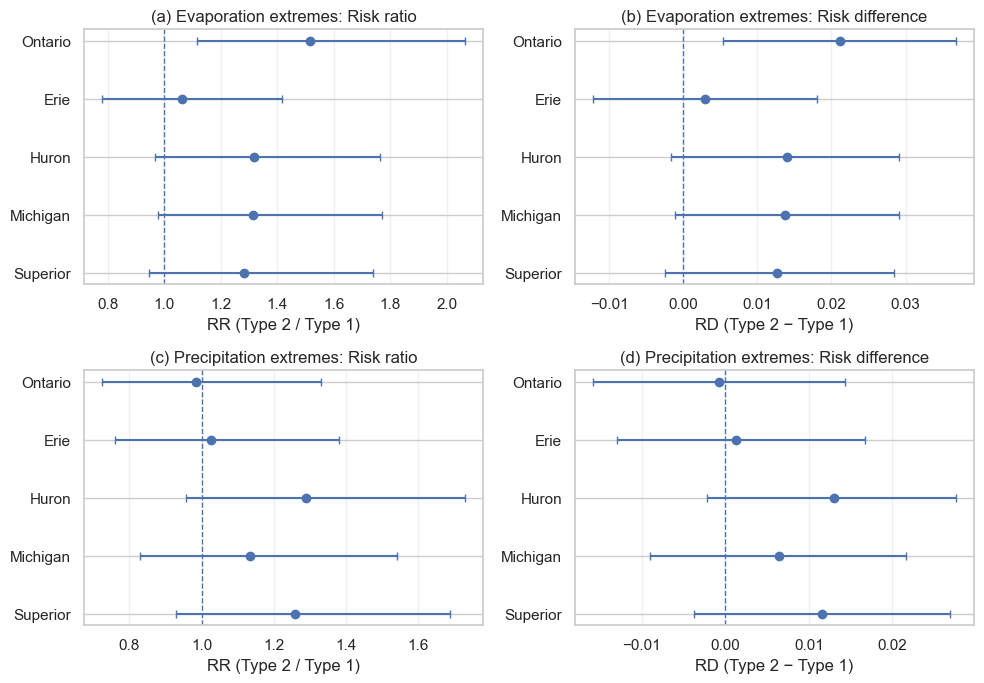

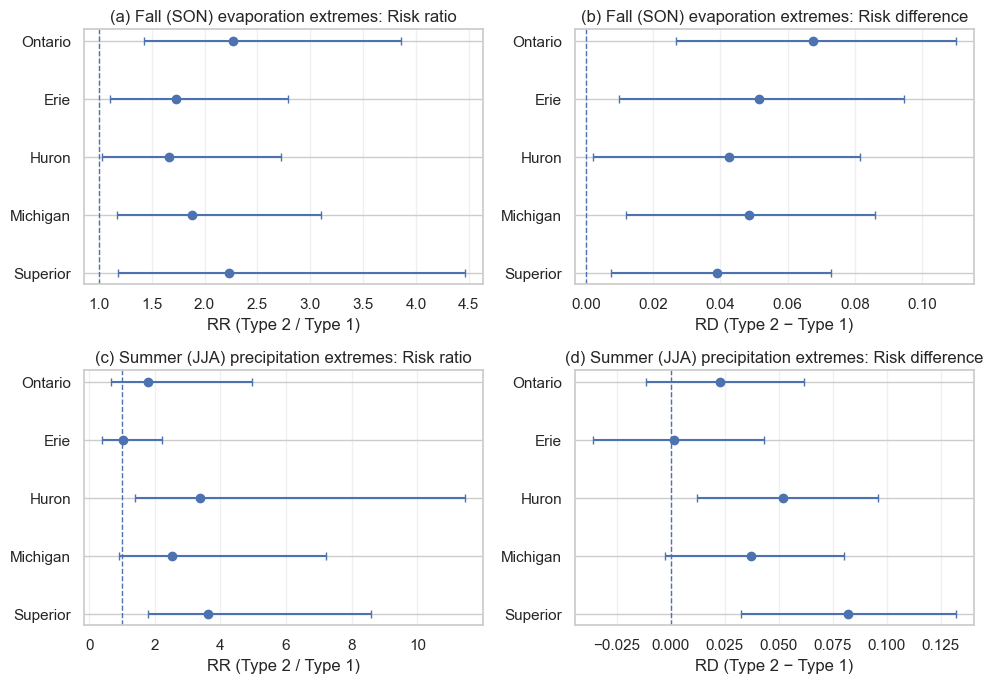

In [12]:
# Key figures
plot_all_seasons_2x2(rr_df_all)
plt.show()

plot_takehome_son_evap_jja_precip(rr_df_seasons)
plt.show()

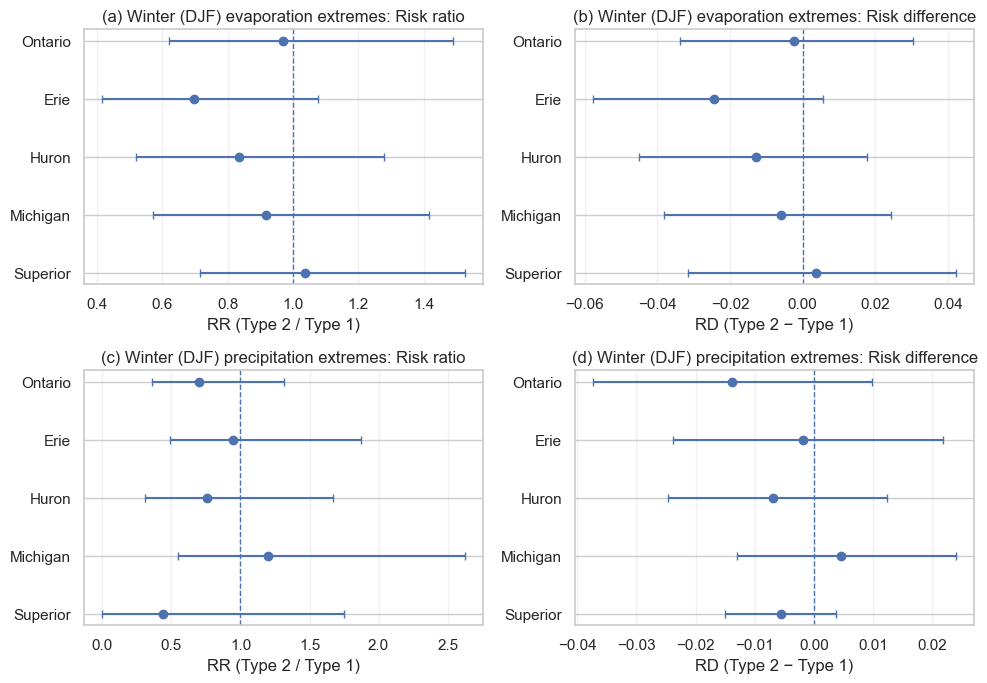

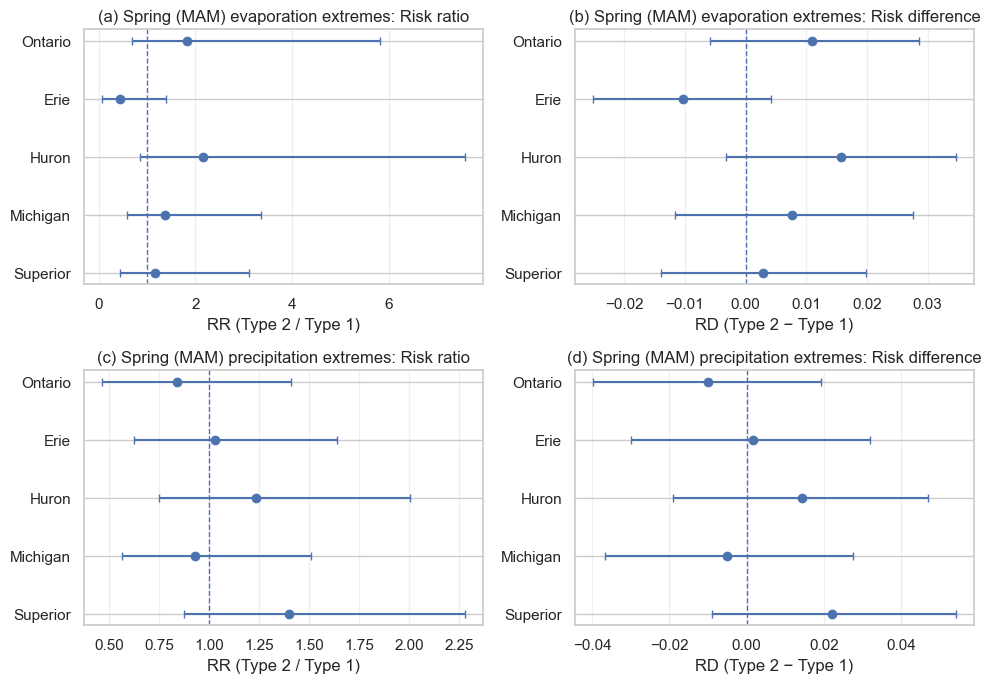

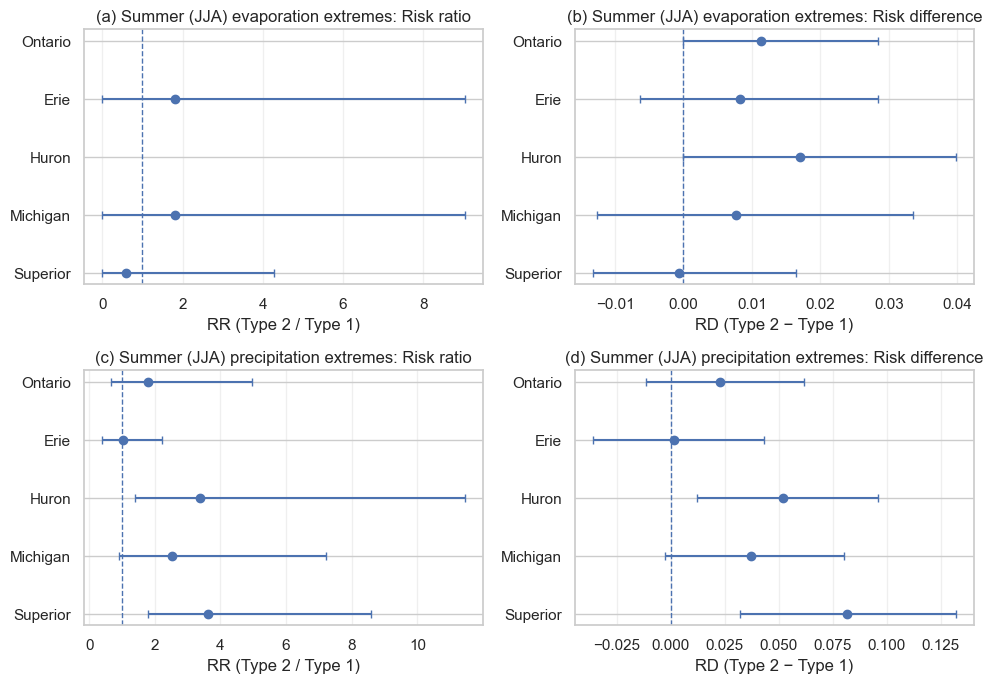

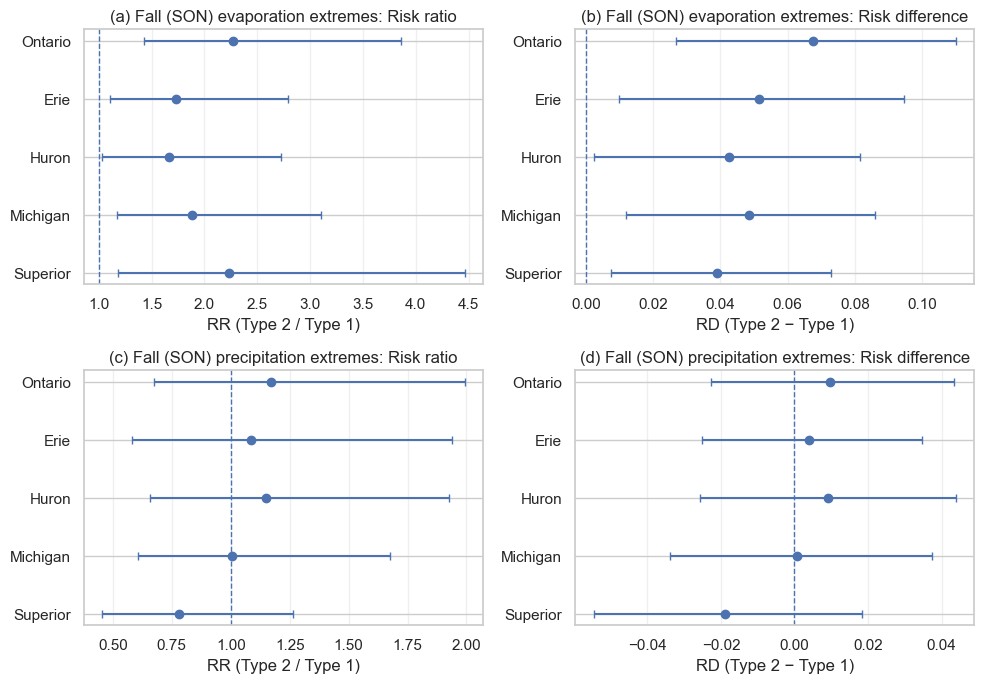

In [13]:
# Optional seasonal figures
for season in SEASON_ORDER:
    plot_season_2x2(rr_df_seasons, season)
    plt.show()

## Diagnostics

These diagnostics summarize the seasonal and monthly distributions of storm types in the labeled storm table. They are useful for interpreting sample sizes and seasonal structure.

In [14]:
# ------------------------------
# 7. Diagnostics
# ------------------------------
season_counts = (
    df.groupby(["season", "storm_type"])
    .size()
    .unstack("storm_type")
    .reindex(SEASON_ORDER)
)

print("Storm counts by season and type:")
display(season_counts)

season_frac = season_counts.div(season_counts.sum(axis=0), axis=1)

print("Storm fractions by season and type:")
display(season_frac)

Storm counts by season and type:


storm_type,Type 1 (Earlier-entry storms),Type 2 (Later-entry storms)
season,,
DJF,597,455
MAM,518,445
JJA,318,176
SON,470,337


Storm fractions by season and type:


storm_type,Type 1 (Earlier-entry storms),Type 2 (Later-entry storms)
season,,
DJF,0.313715,0.322010
MAM,0.272202,0.314933
JJA,0.167105,0.124558
SON,0.246978,0.238500


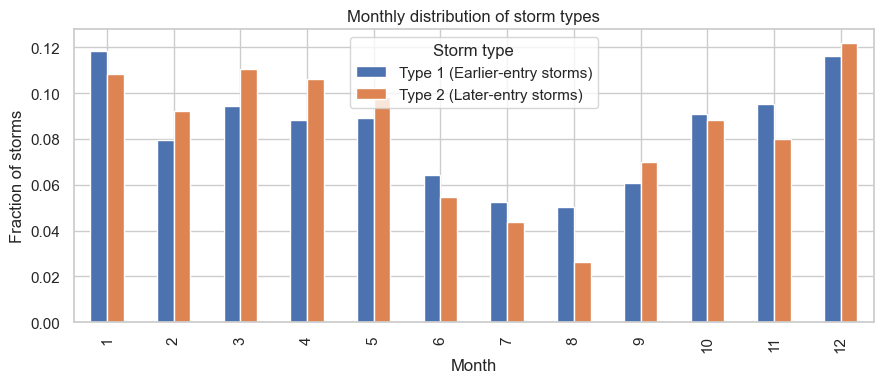

In [15]:
month_counts = (
    df.groupby(["month", "storm_type"])
    .size()
    .unstack("storm_type")
    .sort_index()
)

month_frac = month_counts.div(month_counts.sum(axis=0), axis=1)

ax = month_frac.plot(kind="bar", figsize=(9, 4))
ax.set_ylabel("Fraction of storms")
ax.set_xlabel("Month")
ax.set_title("Monthly distribution of storm types")
ax.legend(title="Storm type")
plt.tight_layout()
plt.show()

## Save figure-ready outputs

Finally, we save the risk-ratio tables, threshold values, and basic diagnostic summaries to the `processed/` directory so that the figure-generation notebook can reproduce the final plots without repeating the full analysis.

In [16]:
# ------------------------------
# 8. Save processed outputs
# ------------------------------
rr_df_all.to_csv(PROCESSED_DIR / "rr_df_all_seasons.csv", index=False)
rr_df_seasons.to_csv(PROCESSED_DIR / "rr_df_by_season.csv", index=False)

pd.Series(precip_thresh, name="precip_95th").to_csv(
    PROCESSED_DIR / "precip_extreme_thresholds.csv"
)
pd.Series(evap_thresh, name="evap_05th").to_csv(
    PROCESSED_DIR / "evap_extreme_thresholds.csv"
)

season_counts.to_csv(PROCESSED_DIR / "storm_counts_by_season_and_type.csv")
season_frac.to_csv(PROCESSED_DIR / "storm_fraction_by_season_and_type.csv")

month_counts.to_csv(PROCESSED_DIR / "storm_counts_by_month_and_type.csv")
month_frac.to_csv(PROCESSED_DIR / "storm_fraction_by_month_and_type.csv")

print("Saved processed outputs for figure reproduction.")

Saved processed outputs for figure reproduction.


## Summary

This notebook defines extreme-impact thresholds, quantifies differences in extreme-impact probability between storm types using risk ratios and risk differences, and saves the resulting summary tables for downstream figure generation.